In [1]:
import sys, os

sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("helper"))

import networkx as nx
from math import gcd
from itertools import combinations
from pathlib import Path
from matplotlib.ticker import MaxNLocator

from plot_utils import (
    np,
    pd,
    plt,
    save_figure,
    load_file,
    read_config_from_csv,
    list_runs,
    FIGURE_SIZE_HALF,
    LINE_STYLE,
    GRID_STYLE,
    REFERENCE_LINE_STYLE,
    EVENT_BOUNDARY_STYLE,
    slate_teal,
    deep_red,
    warm_orange,
    mid_grey,
    navy,
    bordeaux,
    dark_green,
)
from analysis import per_round_counter_delta, index_at_or_before

In [2]:
metrics_path = "../metrics"
FIG_DIR = "../figures/evaluation/stressors"
os.makedirs(FIG_DIR, exist_ok=True)

In [3]:
def round_entry_times(df):
    rounds = df[df.field == "current_round"].copy()
    rounds["v"] = pd.to_numeric(rounds.value, errors="coerce")
    rounds = rounds.dropna(subset=["v"])
    rounds["v"] = rounds["v"].astype(int)
    rounds = rounds[rounds["v"] >= 1]

    earliest_per_round = rounds.groupby(["node", "v"])["time_seconds"].min()
    by_round = earliest_per_round.unstack("v")

    return by_round.sort_index(axis=1)


def full_participants(round_entry):
    seen_every_round = round_entry.notna().all(axis=1)
    return list(round_entry.index[seen_every_round])


def late_joiner(round_entry):
    first_round = round_entry.apply(lambda r: r.first_valid_index(), axis=1)
    late = first_round[first_round > 1].index.tolist()
    assert len(late) <= 1, f"expected at most one late joiner, got {late}"
    return late[0] if late else None


def per_round_last_value(df, field, nodes, round_entry):
    all_rounds = sorted(int(c) for c in round_entry.columns)
    rounds = all_rounds[:-1]

    selected = df[(df.field == field) & (df.node.isin(nodes))].copy()
    selected["v"] = pd.to_numeric(selected.value, errors="coerce")
    selected = selected.dropna(subset=["v"]).sort_values(["node", "time_seconds"])

    result = np.full((len(nodes), len(rounds)), np.nan)
    node_idx = {node: i for i, node in enumerate(nodes)}

    for node, node_rows in selected.groupby("node"):
        times = node_rows.time_seconds.values
        node_values = node_rows.v.values

        for round_pos, round_num in enumerate(rounds):
            start_time = round_entry.at[node, round_num]
            if pd.isna(start_time):
                continue

            end_time = round_entry.at[node, all_rounds[round_pos + 1]]
            if pd.isna(end_time):
                end_time = times[-1] + 1.0

            last_idx = index_at_or_before(times, end_time)
            if last_idx < 0:
                continue

            result[node_idx[node], round_pos] = float(node_values[last_idx])

    return result, rounds


def collect_seed_deltas(seed_paths, fields=("fragments_received", "resent")):
    out = {f: [] for f in fields}
    rounds_seen = None

    for path in seed_paths:
        df = load_file(path)
        df["time_seconds"] = (df["timestamp"] - df["timestamp"].min()).dt.total_seconds()
        round_entry = round_entry_times(df)
        nodes = full_participants(round_entry)

        for field in fields:
            deltas, rounds = per_round_counter_delta(df, field, nodes, round_entry)
            out[field].append(deltas)
            if rounds_seen is None:
                rounds_seen = rounds

    return out, rounds_seen


def collect_seed_gauges(seed_paths, fields=("fragment_completeness",)):
    out = {f: [] for f in fields}
    rounds_seen = None

    for path in seed_paths:
        df = load_file(path)
        df["time_seconds"] = (df["timestamp"] - df["timestamp"].min()).dt.total_seconds()
        round_entry = round_entry_times(df)
        nodes = full_participants(round_entry)

        for field in fields:
            values, rounds = per_round_last_value(df, field, nodes, round_entry)
            out[field].append(values)
            if rounds_seen is None:
                rounds_seen = rounds

    return out, rounds_seen


def per_round_seed_totals(deltas_list):
    return np.array([np.nansum(arr, axis=0) for arr in deltas_list])


def circulant_offsets(n, degree):
    half = degree // 2
    best, best_diam = None, n

    for offsets in combinations(range(1, (n - 1) // 2 + 1), half):
        if gcd(n, *offsets) != 1:
            continue
        if n % 2 == 0 and len({s % 2 for s in offsets}) == 1:
            continue

        diameter = nx.diameter(nx.circulant_graph(n, offsets))
        if diameter < best_diam:
            best_diam, best = diameter, list(offsets)
        if best_diam <= 2:
            break

    return best

In [4]:
X_CUTOFF = 10


def exit_topology_classes(path):
    config = read_config_from_csv(path)
    if config.get("topology_type") != "circulant":
        return None

    node_count = int(config["n_nodes"])
    n_join_late = int(config.get("n_join_late", 0))
    n_exit_early = int(config.get("n_exit_early", 0))
    if n_exit_early == 0:
        return None

    max_hops = int(config.get("max_hops", 2))
    graph = nx.circulant_graph(node_count, circulant_offsets(node_count, int(config["graph_degree"])))
    exiters = set(range(n_join_late, n_join_late + n_exit_early))

    transport, reachable = set(), set()
    for exiter in exiters:
        transport |= set(graph.neighbors(exiter))
        reachable |= {p for p, d in nx.single_source_shortest_path_length(graph, exiter).items() if 0 < d <= max_hops}
    transport -= exiters

    return {
        "A_transport": sorted(transport),
        "B_overlay": sorted(reachable - transport - exiters),
        "C_unaware": sorted(set(range(node_count)) - reachable - transport - exiters),
        "exiters": sorted(exiters),
        "n": node_count,
        "degree": int(config["graph_degree"]),
        "max_hops": max_hops,
    }


def render_exit_topology(classes, out_path):
    node_count = classes["n"]
    graph = nx.circulant_graph(node_count, circulant_offsets(node_count, classes["degree"]))
    pos = {i: (np.cos(2 * np.pi * i / node_count), np.sin(2 * np.pi * i / node_count)) for i in range(node_count)}

    fig, ax = plt.subplots(figsize=FIGURE_SIZE_HALF)
    transport, overlay = set(classes["A_transport"]), set(classes["B_overlay"])

    involved_edges = []

    for exiter in classes["exiters"]:
        for neighbour in graph.neighbors(exiter):
            if neighbour in transport:
                involved_edges.append((exiter, neighbour))

    for transport_node in transport:
        for neighbour in graph.neighbors(transport_node):
            if neighbour in overlay:
                involved_edges.append((transport_node, neighbour))

    nx.draw_networkx_edges(graph, pos, edgelist=involved_edges, ax=ax, edge_color=mid_grey, width=0.6, alpha=0.25)

    color_for = {
        **{i: bordeaux for i in classes["exiters"]},
        **{i: slate_teal for i in classes["A_transport"]},
        **{i: deep_red for i in classes["B_overlay"]},
        **{i: warm_orange for i in classes["C_unaware"]},
    }
    colors = [color_for[i] for i in range(node_count)]
    nx.draw_networkx_nodes(graph, pos, ax=ax, node_color=colors, node_size=60, edgecolors="white", linewidths=0.6)

    from matplotlib.lines import Line2D

    handles = [
        Line2D([0], [0], marker="o", linestyle="None", color=bordeaux, markersize=6, label="exiter"),
        Line2D([0], [0], marker="o", linestyle="None", color=slate_teal, markersize=6, label="A transport"),
        Line2D([0], [0], marker="o", linestyle="None", color=deep_red, markersize=6, label="B overlay"),
        Line2D([0], [0], marker="o", linestyle="None", color=warm_orange, markersize=6, label="C unaware"),
    ]
    ax.legend(handles=handles, loc="center", framealpha=0.9)
    ax.set_aspect("equal")
    ax.axis("off")
    fig.tight_layout()
    save_figure(fig, out_path)
    plt.show()


def render_exit_completeness(exit_paths, classes, out_path):
    if not exit_paths:
        print("no exit_only runs — skipping")
        return

    n_rounds = int(read_config_from_csv(exit_paths[0]).get("n_rounds", 10))
    exit_round = int(np.floor(0.5 * n_rounds))

    per_seed = {cls: [] for cls in ("A_transport", "B_overlay", "C_unaware")}
    rounds_x = None

    for path in exit_paths:
        df = load_file(path)
        df["time_seconds"] = (df["timestamp"] - df["timestamp"].min()).dt.total_seconds()
        round_entry = round_entry_times(df)

        for cls in per_seed:
            class_ids = classes[cls]
            if not class_ids:
                continue

            class_nodes = [f"node_{i}" for i in class_ids]
            values, rounds = per_round_last_value(df, "fragment_completeness", class_nodes, round_entry)
            if values is None or not len(rounds):
                continue

            per_seed[cls].append(np.nanmedian(values, axis=0) / 100.0)
            if rounds_x is None:
                rounds_x = np.array(rounds)

    fig, ax = plt.subplots(figsize=FIGURE_SIZE_HALF)
    palette = {"A_transport": slate_teal, "B_overlay": deep_red, "C_unaware": warm_orange}

    for cls in ("A_transport", "B_overlay", "C_unaware"):
        if not per_seed[cls]:
            continue

        stack = np.vstack(per_seed[cls])
        with np.errstate(all="ignore"):
            center = np.nanmean(stack, axis=0)
            lo = np.nanmin(stack, axis=0)
            hi = np.nanmax(stack, axis=0)

        color = palette[cls]
        ax.fill_between(rounds_x, lo, hi, color=color, alpha=0.2, linewidth=0)
        ax.plot(rounds_x, center, color=color, marker="o", markersize=3, label=cls.replace("_", " "), **LINE_STYLE)

    ax.axvline(exit_round, label=f"Exit (round {exit_round})", **EVENT_BOUNDARY_STYLE)
    ax.set_xlabel("Round")
    ax.set_ylabel("Fragment completeness")
    ax.set_ylim(0.8, 1.02)
    ax.set_xlim(1, X_CUTOFF)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(**GRID_STYLE)
    ax.legend(loc="lower right", framealpha=0.9)
    fig.tight_layout()
    save_figure(fig, out_path)
    plt.show()

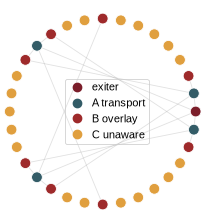

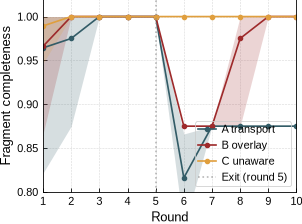

In [5]:
exit_paths = [path for _, path in list_runs(os.path.join(metrics_path, "b1_exit_only"))]

if not exit_paths:
    print("no exit_only runs found — skipping exit figures")
else:

    classes = exit_topology_classes(exit_paths[0])
    if classes is None:
        print("exit run is not circulant — skipping topology partition figure")

    else:
        render_exit_topology(classes, f"{FIG_DIR}/exit_topology.pdf")
        render_exit_completeness(exit_paths, classes, f"{FIG_DIR}/exit_completeness.pdf")

/tmp/ipykernel_651345/3289748671.py:47: RuntimeWarning: Mean of empty slice
  jr_mean = np.nanmean(joiner_recv_frac, axis=0)


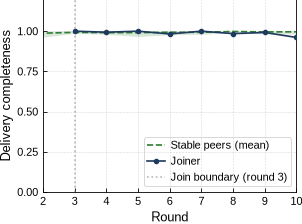

/tmp/ipykernel_651345/3289748671.py:69: RuntimeWarning: Mean of empty slice
  joiner_local_acc_mean = np.nanmean(np.vstack(joiner_local_acc_per_seed), axis=0)


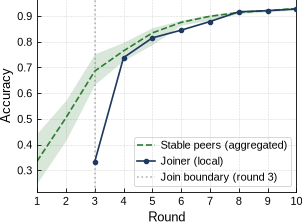

In [6]:
join_paths = [path for _, path in list_runs(os.path.join(metrics_path, "b1_join_only"))]
if not join_paths:
    raise RuntimeError("no join_only runs found")

joiner_recv_per_seed, cohort_recv_per_seed = [], []
joiner_local_acc_per_seed, joiner_agg_acc_per_seed = [], []
cohort_agg_acc_per_seed = []
rounds_seen = None
join_round_seen = None

for path in join_paths:
    df = load_file(path)
    df["time_seconds"] = (df["timestamp"] - df["timestamp"].min()).dt.total_seconds()
    round_entry = round_entry_times(df)
    cohort = full_participants(round_entry)
    joiner = late_joiner(round_entry)
    if joiner is None:
        raise RuntimeError(f"no late joiner in {path}")

    joiner_recv, rounds = per_round_counter_delta(df, "fragments_received", [joiner], round_entry)
    cohort_recv, _ = per_round_counter_delta(df, "fragments_received", cohort, round_entry)
    joiner_local_acc, _ = per_round_last_value(df, "accuracy", [joiner], round_entry)
    joiner_agg_acc, _ = per_round_last_value(df, "aggregated_accuracy", [joiner], round_entry)
    cohort_agg_acc, _ = per_round_last_value(df, "aggregated_accuracy", cohort, round_entry)

    joiner_recv_per_seed.append(joiner_recv[0])
    cohort_recv_per_seed.append(np.nanmean(cohort_recv, axis=0))
    joiner_local_acc_per_seed.append(joiner_local_acc[0])
    joiner_agg_acc_per_seed.append(joiner_agg_acc[0])
    cohort_agg_acc_per_seed.append(cohort_agg_acc)

    if rounds_seen is None:
        rounds_seen = rounds
    if join_round_seen is None:
        join_round_seen = int(round_entry.loc[joiner].first_valid_index())

joiner_recv_arr = np.vstack(joiner_recv_per_seed)
cohort_recv_arr = np.vstack(cohort_recv_per_seed)
rounds_x = np.array(rounds_seen)
join_label = f"Join boundary (round {join_round_seen})"

with np.errstate(all="ignore"):
    cohort_recv_mean = np.nanmean(cohort_recv_arr, axis=0)
    safe = np.where(cohort_recv_mean > 0, cohort_recv_mean, np.nan)
    joiner_recv_frac = np.minimum(joiner_recv_arr / safe, 1.0)
    cohort_recv_frac = np.minimum(cohort_recv_arr / safe, 1.0)
    jr_mean = np.nanmean(joiner_recv_frac, axis=0)
    cr_mean = np.nanmean(cohort_recv_frac, axis=0)
    cr_lo = np.nanmin(cohort_recv_frac, axis=0)
    cr_hi = np.nanmax(cohort_recv_frac, axis=0)

fig, ax = plt.subplots(figsize=FIGURE_SIZE_HALF)
ax.fill_between(rounds_x, cr_lo, cr_hi, color=dark_green, alpha=0.18, linewidth=0)
ax.plot(rounds_x, cr_mean, label="Stable peers (mean)", **REFERENCE_LINE_STYLE)
ax.plot(rounds_x, jr_mean, color=navy, linewidth=1.2, marker="o", markersize=3, zorder=5, label="Joiner")
ax.axvline(join_round_seen, label=join_label, **EVENT_BOUNDARY_STYLE)
ax.set_ylabel("Delivery completeness")
ax.set_xlabel("Round")
ax.set_ylim(0, 1.2)
ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
ax.grid(**GRID_STYLE)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xlim(2, X_CUTOFF)
ax.legend(loc="lower right", framealpha=0.9)
plt.tight_layout()
save_figure(fig, f"{FIG_DIR}/join_delivery.pdf")
plt.show()

joiner_local_acc_mean = np.nanmean(np.vstack(joiner_local_acc_per_seed), axis=0)
cohort_agg_stack = np.vstack(cohort_agg_acc_per_seed)
with np.errstate(all="ignore"):
    ca_mean = np.nanmean(cohort_agg_stack, axis=0)
    ca_lo = np.nanmin(cohort_agg_stack, axis=0)
    ca_hi = np.nanmax(cohort_agg_stack, axis=0)

fig, ax = plt.subplots(figsize=FIGURE_SIZE_HALF)
ax.fill_between(rounds_x, ca_lo, ca_hi, color=dark_green, alpha=0.18, linewidth=0)

ax.plot(rounds_x, ca_mean, label="Stable peers (aggregated)", **REFERENCE_LINE_STYLE)
ax.plot(rounds_x, joiner_local_acc_mean, color=navy, linewidth=1.2, marker="o", markersize=3, zorder=5, label="Joiner (local)")

ax.axvline(join_round_seen, label=join_label, **EVENT_BOUNDARY_STYLE)
ax.set_ylabel("Accuracy")
ax.set_xlabel("Round")

ax.grid(**GRID_STYLE)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xlim(1, X_CUTOFF)
ax.legend(loc="lower right", framealpha=0.9)

plt.tight_layout()
save_figure(fig, f"{FIG_DIR}/join_accuracy.pdf")
plt.show()